### 2 a) Incorporación de un tercer elemento: El modelo $WK_3$
El modelo de 2 elementos presenta una limitación: no modela correctamente la relación presión-flujo durante la fase inicial de la sístole (altas frecuencias). Para corregir esto, se incorpora un tercer parámetro: la **Impedancia Característica Aórtica ($Z_c$)**.

Este elemento modela la resistencia local e inercial de la raíz aórtica ante la llegada de la onda de flujo pulsátil, vinculando el modelo de parámetros concentrados con los fenómenos de transmisión de ondas a lo largo del árbol arterial.

Matemáticamente, $Z_c$ se coloca en serie con el sistema, por lo que la presión aórtica total será la suma de la presión sobre la compliance ($P_c$, calculada igual que en el $WK_2$) más la caída de presión instantánea generada por el flujo al atravesar $Z_c$ ($Q \cdot Z_c$).

In [6]:
# -------------------------------------------------------------------------
# MÓDULOS DE USO GENERAL Y FUNCIÓN DE FLUJO
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    Escala_ml = 1e5 * (Qmax / 8.8)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [7]:
# -------------------------------------------------------------------------
# SOLVERS PARA WK2 Y WK3
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = 80.0
    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)
    return P

def resolver_wk3_euler(Q, t, Ca, Rp, Zc):
    dt = t[1] - t[0]
    Pc = np.zeros(len(t))
    P_ao = np.zeros(len(t))

    Pc[0] = 80.0
    P_ao[0] = Pc[0] + (Q[0] * Zc)

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (Pc[i-1] / (Rp * Ca))
        Pc[i] = Pc[i-1] + (dP_dt * dt)
        P_ao[i] = Pc[i] + (Q[i] * Zc)

    return P_ao

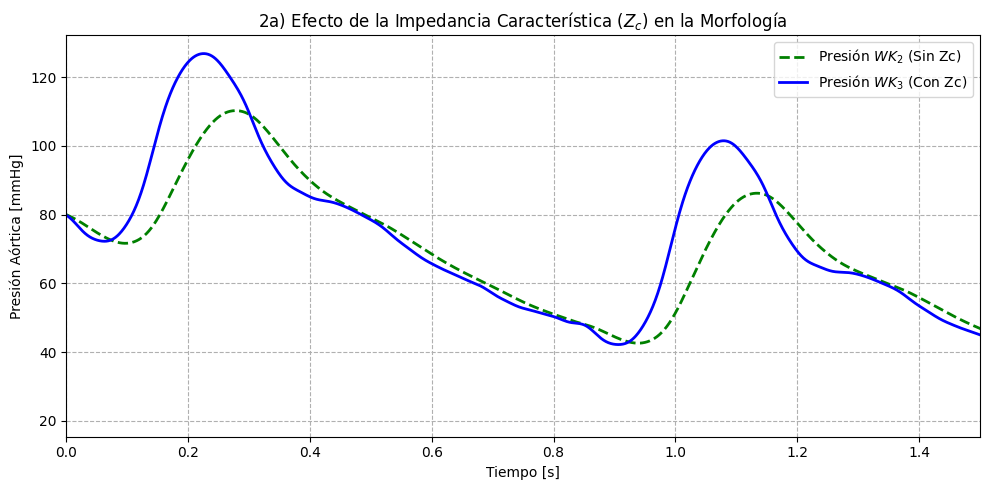

In [8]:
# -------------------------------------------------------------------------
# SIMULACIÓN 2a: WK2 vs WK3
# -------------------------------------------------------------------------

Ts = 0.001
t = np.arange(0, 5, Ts)
T0 = 0.85
Qmax = 500
Q_entrada = Q_Sim(Qmax, T0, t)

Ca_basal = 1.1
Rp_basal = 0.9
Zc_basal = 0.06

P_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_basal, Rp_basal)
P_wk3 = resolver_wk3_euler(Q_entrada, t, Ca_basal, Rp_basal, Zc_basal)

plt.figure(figsize=(10, 5))
plt.plot(t, P_wk2, '--', color='green', linewidth=2, label='Presión $WK_2$ (Sin Zc)')
plt.plot(t, P_wk3, color='blue', linewidth=2, label='Presión $WK_3$ (Con Zc)')
plt.xlim(0, 1.5) # Zoom a los primeros latidos
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión Aórtica [mmHg]')
plt.title('2a) Efecto de la Impedancia Característica ($Z_c$) en la Morfología')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión del análisis (2 a)
Al comparar las morfologías, observamos que la incorporación de la **Impedancia Característica ($Z_c$)** soluciona una anomalía evidente del $WK_2$.

En el $WK_2$ (línea verde punteada), la presión sube de manera muy suave y "filtrada" durante la sístole. Sin embargo, en el $WK_3$ (línea azul), la curva de presión exhibe una **pendiente de ascenso mucho más pronunciada** al inicio de la sístole, seguida de un pico más definido. Esto ocurre porque el término $Q(t) \cdot Z_c$ acopla la forma abrupta de la onda de flujo (altas frecuencias) directamente a la señal de presión. Este comportamiento es muchísimo más fiel a los registros invasivos reales medidos en la raíz aórtica humana.